## Import Libraries and Data


In [204]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA  
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import classification_report, accuracy_score
import joblib
import scipy.cluster.hierarchy as sch
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.cluster import KMeans
file_path = r"C:\Users\nerme\Downloads\archive\heart.csv"
df = pd.read_csv(file_path)

## Initial Data Exploration

In [205]:
print("First 5 records:\n", df.head())

First 5 records:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [206]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [207]:
df.shape

(303, 14)

In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [209]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [210]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [211]:
dupval=df.duplicated().any()
print(dupval)


True


In [212]:
df=df.drop_duplicates()

In [213]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [214]:
df.shape

(302, 14)

## EDA

In [215]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


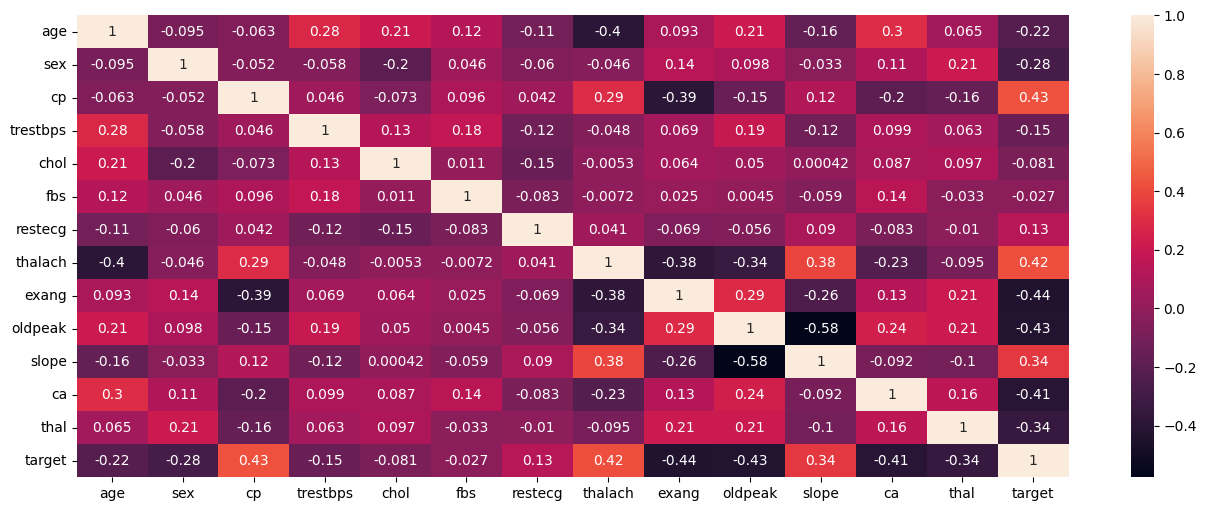

In [216]:
plt.figure(figsize=(16,6))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [217]:
df.columns



Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

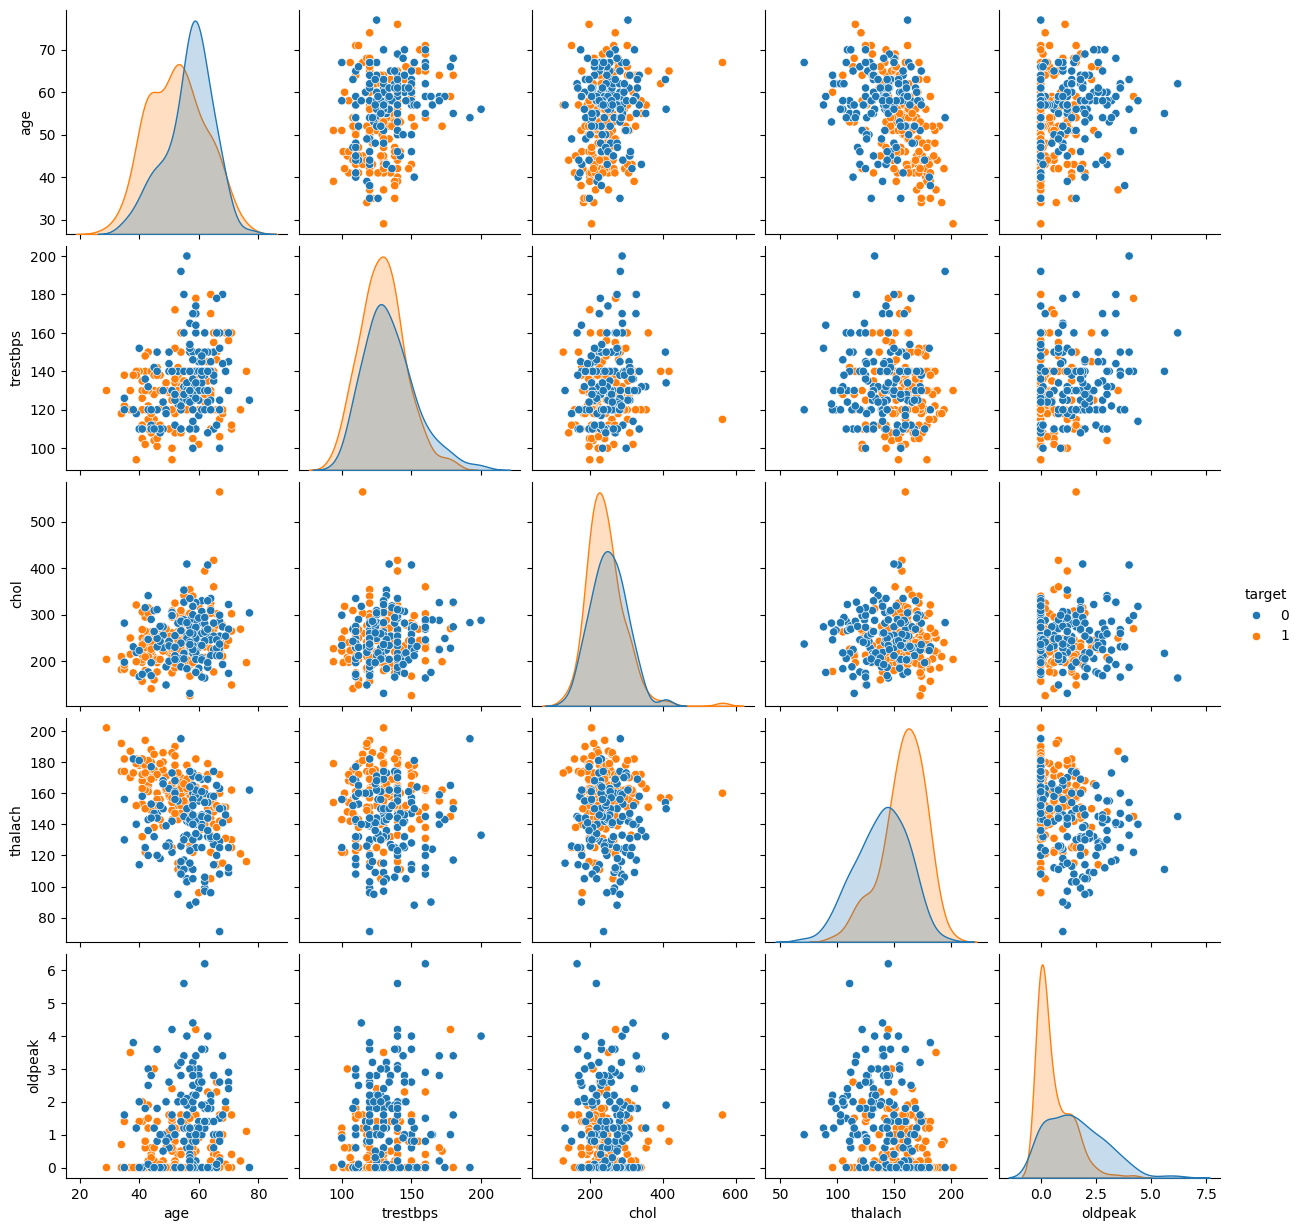

In [218]:
sns.pairplot(df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']], hue='target')
plt.show()


C:\Users\nerme\AppData\Local\Temp\ipykernel_9084\1507670928.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['female', 'male'])


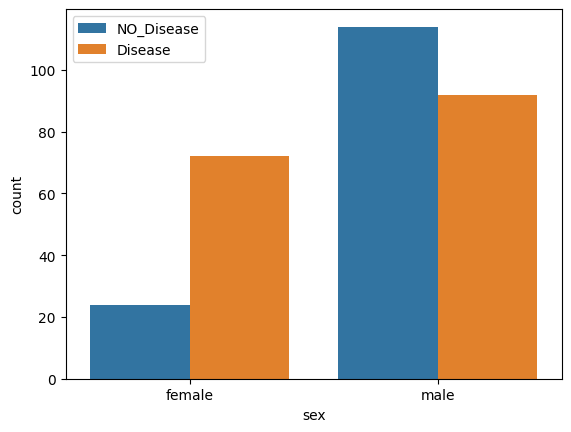

In [219]:
ax = sns.countplot(x="sex", data=df, hue="target")
ax.set_xticklabels(['female', 'male'])
plt.legend(labels=['NO_Disease', 'Disease'])
plt.show()



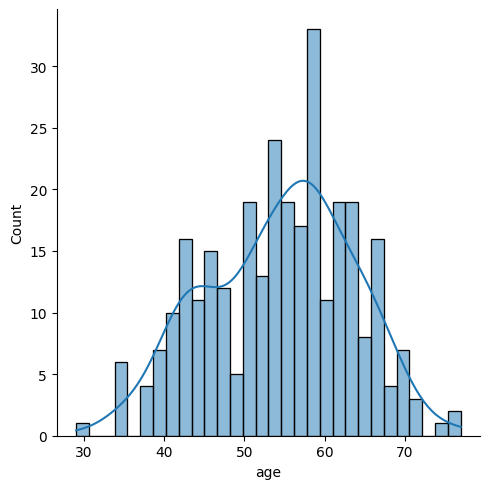

In [220]:
sns.displot(df['age'], bins=30, kde=True)

plt.show()


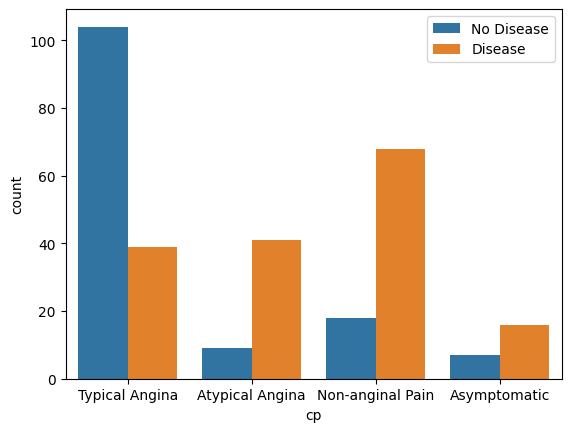

In [221]:
ax = sns.countplot(x="cp", data=df ,hue="target")

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'])
plt.legend(labels=['No Disease', 'Disease'])
plt.show()




<Axes: >

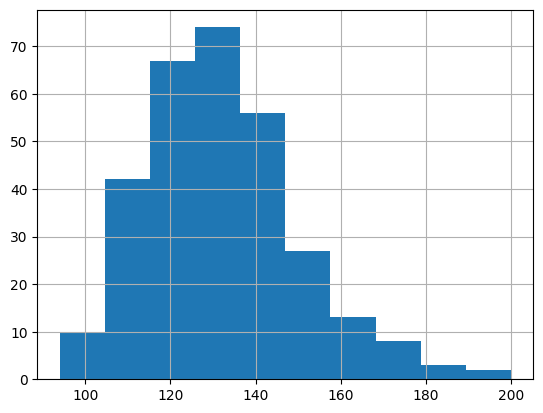

In [222]:
df[ 'trestbps'].hist()



<Axes: >

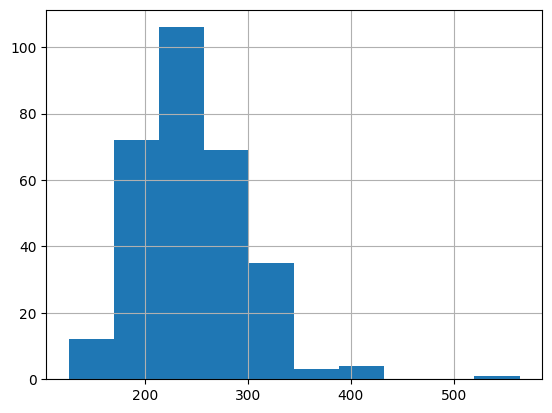

In [223]:

df['chol'].hist()


## Preprocessing

In [224]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
target = 'target'
numeric_transformer=StandardScaler()
categorical_transformer=OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [225]:
X = df.drop(columns=[target])   
y = df[target]               
X_preprocessed = preprocessor.fit_transform(X)
print("Shape of X_preprocessed:", X_preprocessed.shape)

Shape of X_preprocessed: (302, 30)


In [226]:
X = df.drop('target', axis=1)  
y = df['target']            

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,    
    random_state=42,
    stratify=y      
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Feature Selection

In [227]:
chi_selector = SelectKBest(score_func=chi2, k=8)
chi_selector.fit(abs(X_train_scaled), y_train)


X_train_selected = chi_selector.transform(abs(X_train_scaled))
X_test_selected = chi_selector.transform(abs(X_test_scaled))

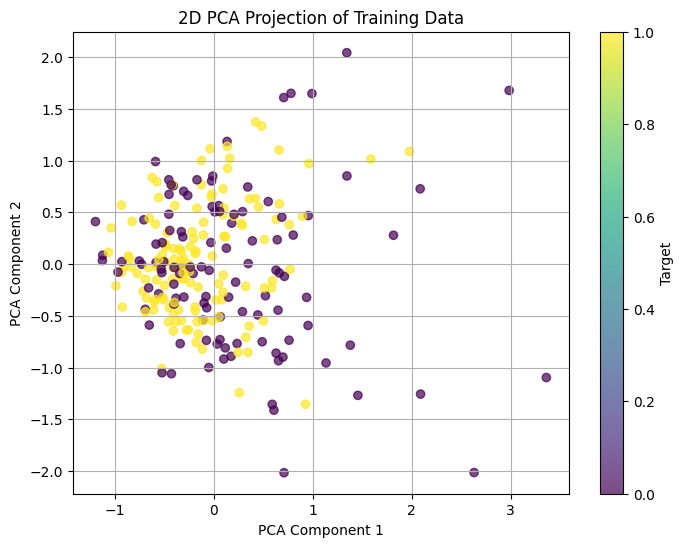

In [228]:

pca = PCA(n_components=5)
pca.fit(X_train_selected)

X_train_pca = pca.transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D PCA Projection of Training Data')
plt.colorbar(label='Target')
plt.grid(True)
plt.show()


## Models

In [229]:
models={
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}
for name,model in models.items():
    model.fit(X_train_pca,y_train)
  
    y_pred = model.predict(X_test_pca)
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))


Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.63      0.61      0.62        28
           1       0.68      0.70      0.69        33

    accuracy                           0.66        61
   macro avg       0.65      0.65      0.65        61
weighted avg       0.65      0.66      0.66        61


Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.54      0.54      0.54        28
           1       0.61      0.61      0.61        33

    accuracy                           0.57        61
   macro avg       0.57      0.57      0.57        61
weighted avg       0.57      0.57      0.57        61


Random Forest Performance:
              precision    recall  f1-score   support

           0       0.61      0.61      0.61        28
           1       0.67      0.67      0.67        33

    accuracy                           0.64        61
   macro avg       0.64      0.64     

## K-Means Clustering + Elbow Method

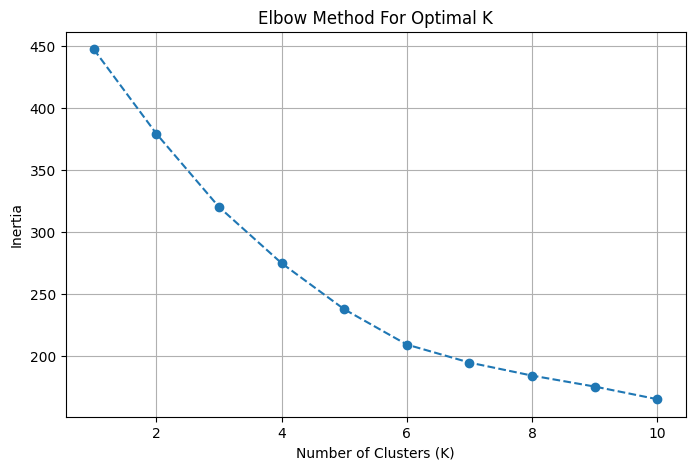

In [230]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_pca)  
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.show()

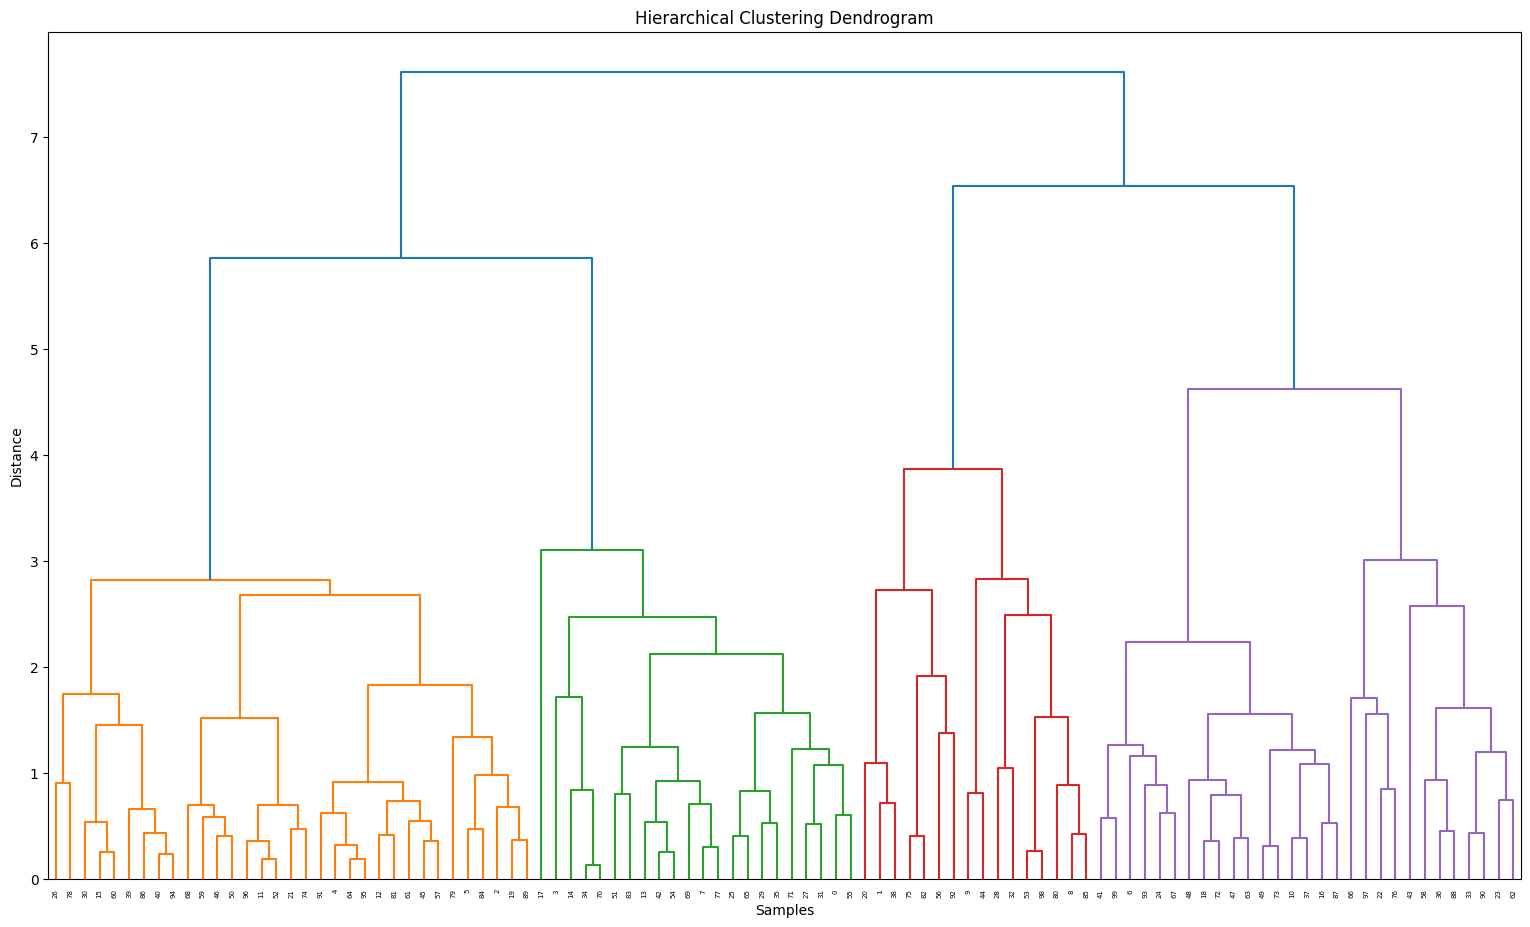

In [231]:
sample_data = X_train_pca[:100]  

linked = linkage(sample_data, method='ward')

plt.figure(figsize=(19, 11))
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [232]:
kmeans = KMeans(n_clusters=2, random_state=42)  
clusters = kmeans.fit_predict(X_train_pca)

score = adjusted_rand_score(y_train, clusters)
print("Adjusted Rand Index:", score)

Adjusted Rand Index: 0.014208528791993707


In [233]:

param_dist = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=10, cv=3, scoring='accuracy')
random_search.fit(X_train_pca, y_train)

print("Best Parameters (Randomized):", random_search.best_params_)

Best Parameters (Randomized): {'n_estimators': 150, 'min_samples_split': 2, 'max_depth': 10}


In [234]:
param_grid = {
    "n_estimators": [100, 120],
    "max_depth": [5, 10]
}

grid_search = GridSearchCV(rf, param_grid=param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_pca, y_train)

print("Best Parameters (Grid):", grid_search.best_params_)

Best Parameters (Grid): {'max_depth': 10, 'n_estimators': 120}


In [235]:
best_rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    random_state=42
)

best_rf.fit(X_train_pca, y_train)
y_pred = best_rf.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.5737704918032787
              precision    recall  f1-score   support

           0       0.54      0.50      0.52        28
           1       0.60      0.64      0.62        33

    accuracy                           0.57        61
   macro avg       0.57      0.57      0.57        61
weighted avg       0.57      0.57      0.57        61



In [236]:
joblib.dump(model, 'model.pkl')

['model.pkl']